In [1]:
# ============================================================
# 0. DEFENSIVE PATH SETUP
# ============================================================
# This cell is safe to run independently before any analysis cell.
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Projects\OASIS\oasis_raw_t1_encoder"
)

PAPER_OUTPUT_DIR = (
    PROJECT_ROOT / "PAPER_READY_FINAL_RESULTS"
)

REPEAT_DIR = (
    PAPER_OUTPUT_DIR / "outer_repeats"
)

PAPER_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPEAT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PAPER_OUTPUT_DIR:", PAPER_OUTPUT_DIR)
print("REPEAT_DIR:", REPEAT_DIR)


PROJECT_ROOT: C:\Projects\OASIS\oasis_raw_t1_encoder
PAPER_OUTPUT_DIR: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS
REPEAT_DIR: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS\outer_repeats


# OASIS-3 Raw-T1 Longitudinal Multimodal Reliability, FINAL Upgraded Notebook

## Purpose

This notebook starts **after Triad extraction**. It reuses the saved 1488-dimensional raw-T1 embeddings and performs the longitudinal ML/reliability experiment.

### Central ML question

> **Can a frozen pretrained raw-T1 representation identify when MRI and clinical views of a patient's evolving state disagree, and does that disagreement identify predictive unreliability beyond conventional model uncertainty?**

### Core design

```text
Saved Triad MRI embedding per MRI session
                    +
            longitudinal clinical history
                    ↓
       independent temporal encoders
                    ↓
        ┌───────────┴───────────┐
        ↓                       ↓
    MRI predictor         Clinical predictor
        ↓                       ↓
          MRI-clinical prediction disagreement
                    +
              latent disagreement
                    +
          ensemble predictive uncertainty
                    ↓
          joint multimodal prediction
                    ↓
              prediction error
```

### Important implementation guarantees

- No Triad re-extraction.
- No raw NIfTI processing.
- MRI runs are already resolved to one acquisition per biological MRI session.
- Subject-disjoint train/test split.
- Grouped OOF evaluation.
- Fold-local scaler and PCA, so validation/test rows never fit their own preprocessing.
- MRI and clinical heads are explicitly supervised.
- Persistence is defined as anchor MMSE predicting future MMSE.
- Large-error threshold is learned from OOF development data only.
- Held-out reliability scores do not use held-out outcomes.
- Ensemble uncertainty comes from independently trained models.
- Clustering is exploratory representation sanity checking, not phenotype discovery.


In [2]:
# ============================================================
# 1. IMPORTS + GLOBAL CONFIG
# ============================================================

import gc
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
    silhouette_score,
    adjusted_rand_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

OASIS_STRUCTURED_ROOT = Path(
    r"C:\Projects\OASIS\OASIS3_data_files"
)

EMBEDDING_ROOT = Path(
    r"C:\Projects\OASIS\oasis_raw_t1_encoder\triad_embeddings"
)

EMBEDDING_MANIFEST = (
    EMBEDDING_ROOT / "embedding_manifest.csv"
)

OUTPUT_DIR = Path(
    r"C:\Projects\OASIS\oasis_raw_t1_encoder\FINAL_LONGITUDINAL_RESULTS"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# PROJECT PATH ALIASES
# ------------------------------------------------------------
# Keep a single project root so auxiliary cells can safely use
# PROJECT_ROOT / PAPER_OUTPUT_DIR / REPEAT_DIR as aliases.
PROJECT_ROOT = Path(
    r"C:\Projects\OASIS\oasis_raw_t1_encoder"
)

PAPER_OUTPUT_DIR = (
    PROJECT_ROOT / "PAPER_READY_FINAL_RESULTS"
)

REPEAT_DIR = (
    PAPER_OUTPUT_DIR / "outer_repeats"
)

PAPER_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPEAT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)



# ------------------------------------------------------------
# COHORT SETTINGS
# ------------------------------------------------------------

MRI_CLINICAL_MATCH_WINDOW_DAYS = 180

MIN_FUTURE_DAYS = 180
MAX_FUTURE_DAYS = 730

MAX_MRI_HISTORY = 6
MAX_CLINICAL_HISTORY = 8


# ------------------------------------------------------------
# MODEL SETTINGS
# ------------------------------------------------------------

PCA_DIM = 64

TEMPORAL_HIDDEN = 32

BATCH_SIZE = 16

MAX_EPOCHS = 100
PATIENCE = 15

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4

INNER_VALID_FRACTION = 0.15

N_OOF_FOLDS = 5

# OOF uncertainty ensemble
N_OOF_UNCERTAINTY_MEMBERS = 3

# Final held-out ensemble
N_TEST_ENSEMBLE_MEMBERS = 5

LARGE_ERROR_QUANTILE = 0.75


print("\nOutput:", OUTPUT_DIR)
print("Embedding root:", EMBEDDING_ROOT)


PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU

Output: C:\Projects\OASIS\oasis_raw_t1_encoder\FINAL_LONGITUDINAL_RESULTS
Embedding root: C:\Projects\OASIS\oasis_raw_t1_encoder\triad_embeddings


## 2. Load structured OASIS tables

In [3]:
# ============================================================
# 2. LOAD STRUCTURED OASIS DATA
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# ROOT
# ------------------------------------------------------------

OASIS_STRUCTURED_ROOT = Path(
    r"C:\Projects\OASIS\OASIS3_data_files"
)

if not OASIS_STRUCTURED_ROOT.exists():
    raise FileNotFoundError(
        f"OASIS root does not exist:\n"
        f"{OASIS_STRUCTURED_ROOT}"
    )


# ------------------------------------------------------------
# FIND EXACT CSV BY FILENAME
# ------------------------------------------------------------

def find_unique_file(
    root,
    filename,
):
    """
    Search recursively for an exact filename.

    This avoids dependence on small differences in the
    downloaded OASIS folder names.
    """

    matches = list(
        root.rglob(filename)
    )

    # Remove non-files
    matches = [
        p for p in matches
        if p.is_file()
    ]

    if len(matches) == 0:

        raise FileNotFoundError(
            f"Could not find:\n"
            f"  {filename}\n\n"
            f"under:\n"
            f"  {root}"
        )

    if len(matches) > 1:

        print(
            f"WARNING: found {len(matches)} copies of "
            f"{filename}. Using the first:"
        )

        for p in matches:
            print(
                "  ",
                p
            )

    return matches[0]


# ============================================================
# 1. LOCATE REQUIRED FILES
# ============================================================

DEMO_FILE = find_unique_file(
    OASIS_STRUCTURED_ROOT,
    "OASIS3_demographics.csv",
)

FS_FILE = find_unique_file(
    OASIS_STRUCTURED_ROOT,
    "OASIS3_Freesurfer_output.csv",
)

B4_FILE = find_unique_file(
    OASIS_STRUCTURED_ROOT,
    "OASIS3_UDSb4_cdr.csv",
)


# C1 is not currently required for the raw-T1 experiment,
# but locate it if present for completeness.

C1_CANDIDATES = list(
    OASIS_STRUCTURED_ROOT.rglob(
        "OASIS3_UDSc1_cognitive_assessments.csv"
    )
)

C1_FILE = (
    C1_CANDIDATES[0]
    if C1_CANDIDATES
    else None
)


# ============================================================
# 2. PRINT EXACT PATHS
# ============================================================

print("=" * 72)
print("OASIS STRUCTURED DATA FILES")
print("=" * 72)

print(
    "Demographics:",
    DEMO_FILE.exists(),
    "->",
    DEMO_FILE,
)

print(
    "FreeSurfer:",
    FS_FILE.exists(),
    "->",
    FS_FILE,
)

print(
    "B4:",
    B4_FILE.exists(),
    "->",
    B4_FILE,
)

print(
    "C1:",
    C1_FILE is not None,
    "->",
    C1_FILE,
)


# ============================================================
# 3. LOAD
# ============================================================

demo = pd.read_csv(
    DEMO_FILE,
    low_memory=False,
)

fs = pd.read_csv(
    FS_FILE,
    low_memory=False,
)

b4 = pd.read_csv(
    B4_FILE,
    low_memory=False,
)


if C1_FILE is not None:

    c1 = pd.read_csv(
        C1_FILE,
        low_memory=False,
    )

else:

    c1 = None


# ============================================================
# 4. SHAPES
# ============================================================

print("\n" + "=" * 72)
print("TABLE SHAPES")
print("=" * 72)

print(
    "demo:",
    demo.shape,
)

print(
    "fs:",
    fs.shape,
)

print(
    "b4:",
    b4.shape,
)

if c1 is not None:

    print(
        "c1:",
        c1.shape,
    )
else:

    print(
        "c1: not loaded"
    )


# ============================================================
# 5. BASIC COLUMN VALIDATION
# ============================================================

required_demo = [
    "OASISID",
]

required_fs = [
    "Subject",
    "MR_session",
]

required_b4 = [
    "OASISID",
    "days_to_visit",
    "MMSE",
    "CDRSUM",
    "CDRTOT",
    "age at visit",
]


def check_columns(
    df,
    required,
    name,
):

    missing = [
        c
        for c in required
        if c not in df.columns
    ]

    if missing:

        raise KeyError(
            f"{name} missing required columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n"
            f"{df.columns.tolist()}"
        )


check_columns(
    demo,
    required_demo,
    "demographics",
)

check_columns(
    fs,
    required_fs,
    "FreeSurfer",
)

check_columns(
    b4,
    required_b4,
    "B4",
)


print(
    "\nAll required structured columns found."
)

OASIS STRUCTURED DATA FILES
Demographics: True -> C:\Projects\OASIS\OASIS3_data_files\scans\demo-demographics\resources\csv\files\OASIS3_demographics.csv
FreeSurfer: True -> C:\Projects\OASIS\OASIS3_data_files\scans\FS-Freesurfer_output\resources\csv\files\OASIS3_Freesurfer_output.csv
B4: True -> C:\Projects\OASIS\OASIS3_data_files\scans\UDSb4-Form_B4__Global_Staging__CDR__Standard_and_Supplemental\resources\csv\files\OASIS3_UDSb4_cdr.csv
C1: True -> C:\Projects\OASIS\OASIS3_data_files\scans\pychometrics-Form_C1__Cognitive_Assessments\resources\csv\files\OASIS3_UDSc1_cognitive_assessments.csv

TABLE SHAPES
demo: (1378, 19)
fs: (2681, 203)
b4: (8626, 23)
c1: (7924, 107)

All required structured columns found.


In [4]:
# ============================================================
# 3. STANDARDIZE IDs / DATES / CLINICAL VARIABLES
# ============================================================

def clean_subject_id(x):
    s = str(x).upper()
    m = re.search(r"OAS\d{5}", s)
    return m.group(0) if m else np.nan


def extract_days(x):
    m = re.search(
        r"[._-]d(\d{4,5})(?:\D|$)",
        str(x),
        flags=re.IGNORECASE,
    )
    return int(m.group(1)) if m else np.nan


import re

demo["subject_id"] = (
    demo["OASISID"].apply(clean_subject_id)
)

fs["subject_id"] = (
    fs["Subject"].apply(clean_subject_id)
)

b4["subject_id"] = (
    b4["OASISID"].apply(clean_subject_id)
)

fs["mri_day"] = (
    fs["MR_session"].apply(extract_days)
)

b4["clinical_day"] = pd.to_numeric(
    b4["days_to_visit"],
    errors="coerce",
)

clinical = b4[
    [
        "subject_id",
        "clinical_day",
        "age at visit",
        "MMSE",
        "CDRSUM",
        "CDRTOT",
    ]
].copy()

clinical = clinical.rename(
    columns={
        "age at visit": "age_visit",
        "MMSE": "mmse",
        "CDRSUM": "cdrsum",
        "CDRTOT": "cdrtot",
    }
)

for c in [
    "clinical_day",
    "age_visit",
    "mmse",
    "cdrsum",
    "cdrtot",
]:
    clinical[c] = pd.to_numeric(
        clinical[c],
        errors="coerce",
    )

clinical = (
    clinical
    .dropna(
        subset=[
            "subject_id",
            "clinical_day",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "clinical_day",
        ]
    )
    .drop_duplicates(
        [
            "subject_id",
            "clinical_day",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

mri = fs[
    [
        "subject_id",
        "mri_day",
    ]
].copy()

mri["mri_day"] = pd.to_numeric(
    mri["mri_day"],
    errors="coerce",
)

mri = (
    mri
    .dropna(
        subset=[
            "subject_id",
            "mri_day",
        ]
    )
    .drop_duplicates(
        [
            "subject_id",
            "mri_day",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "mri_day",
        ]
    )
    .reset_index(drop=True)
)

print("Clinical rows:", len(clinical))
print("Clinical subjects:", clinical["subject_id"].nunique())
print("MRI visits:", len(mri))
print("MRI subjects:", mri["subject_id"].nunique())


Clinical rows: 8626
Clinical subjects: 1378
MRI visits: 2681
MRI subjects: 1316


## 4. Load and verify the completed Triad embedding cache

In [5]:
# ============================================================
# 4. LOAD COMPLETED TRIAD EMBEDDINGS
# ============================================================

if not EMBEDDING_ROOT.exists():
    raise FileNotFoundError(
        f"Embedding directory not found: {EMBEDDING_ROOT}"
    )

if not EMBEDDING_MANIFEST.exists():
    raise FileNotFoundError(
        f"Embedding manifest not found: {EMBEDDING_MANIFEST}"
    )

embedding_manifest = pd.read_csv(
    EMBEDDING_MANIFEST
)

required_cols = [
    "subject_id",
    "session",
    "mri_day",
    "embedding_path",
    "embedding_dim",
    "status",
]

missing = [
    c
    for c in required_cols
    if c not in embedding_manifest.columns
]

if missing:
    raise KeyError(
        f"Embedding manifest missing columns: {missing}"
    )

embedding_manifest["subject_id"] = (
    embedding_manifest["subject_id"]
    .astype(str)
    .str.upper()
    .str.extract(r"(OAS\d{5})", expand=False)
)

embedding_manifest["mri_day"] = pd.to_numeric(
    embedding_manifest["mri_day"],
    errors="coerce",
)

embedding_manifest["embedding_dim"] = pd.to_numeric(
    embedding_manifest["embedding_dim"],
    errors="coerce",
)

embedding_manifest = embedding_manifest[
    embedding_manifest["status"].eq("OK")
    &
    embedding_manifest["embedding_dim"].eq(1488)
].copy()


def resolve_embedding_path(x):
    p = Path(str(x))
    if p.is_absolute():
        return p
    return EMBEDDING_ROOT / p.name


embedding_manifest["embedding_path"] = (
    embedding_manifest["embedding_path"]
    .map(resolve_embedding_path)
)

verified = []

for p in embedding_manifest["embedding_path"]:

    try:
        z = np.load(
            p,
            mmap_mode="r",
        )

        ok = (
            z.ndim == 1
            and z.shape[0] == 1488
            and np.isfinite(
                np.asarray(z)
            ).all()
        )

    except Exception:
        ok = False

    verified.append(ok)

embedding_manifest = (
    embedding_manifest.loc[verified]
    .drop_duplicates(
        [
            "subject_id",
            "mri_day",
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

print("=" * 72)
print("TRIAD EMBEDDING CACHE")
print("=" * 72)

print(
    "Verified 1488-D embeddings:",
    len(embedding_manifest),
)

print(
    "Subjects:",
    embedding_manifest["subject_id"].nunique(),
)

print(
    "MRI sessions:",
    embedding_manifest[
        [
            "subject_id",
            "mri_day",
        ]
    ].drop_duplicates().shape[0],
)


TRIAD EMBEDDING CACHE
Verified 1488-D embeddings: 2155
Subjects: 1093
MRI sessions: 2155


## 5. Build the MRI-clinical anchor and future-outcome cohort

This section is self-contained. It defines `selected_t1`, `anchor_match`, and `prediction_cohort` before any longitudinal history code can reference them.

In [6]:
# ============================================================
# 5. BUILD MRI-CLINICAL ANCHORS + FUTURE MMSE COHORT
# ============================================================
# This cell is self-contained and MUST run before longitudinal
# history construction. It fixes the previous execution-order bug
# where prediction_cohort was referenced before being defined.

def match_mri_to_clinical(mri_df, clinical_df, window_days=180):
    """
    For each clinical visit, choose the closest MRI acquired on or
    before that visit, provided the MRI-clinical gap is <= window_days.
    This preserves temporal causality for prediction.
    """
    rows = []

    mri_groups = {
        sid: g.sort_values("mri_day")
        for sid, g in mri_df.groupby("subject_id")
    }

    for _, c in clinical_df.iterrows():
        sid = c["subject_id"]
        cday = float(c["clinical_day"])

        if sid not in mri_groups:
            continue

        g = mri_groups[sid]
        eligible = g[
            (g["mri_day"] <= cday)
            & ((cday - g["mri_day"]) <= window_days)
        ]

        if eligible.empty:
            continue

        idx = (cday - eligible["mri_day"]).abs().idxmin()
        m = eligible.loc[idx]

        rows.append({
            "subject_id": sid,
            "clinical_day": cday,
            "mri_day": float(m["mri_day"]),
            "gap_days": cday - float(m["mri_day"]),
            "mmse": c.get("mmse", np.nan),
            "age_visit": c.get("age_visit", np.nan),
            "cdrsum": c.get("cdrsum", np.nan),
            "cdrtot": c.get("cdrtot", np.nan),
        })

    return pd.DataFrame(rows)


def add_future_outcome(anchors_df, clinical_df, min_days=180, max_days=730):
    """
    Add the first future clinical visit with a valid MMSE occurring
    between min_days and max_days after the anchor clinical visit.
    """
    clinical_groups = {
        sid: g.sort_values("clinical_day")
        for sid, g in clinical_df.groupby("subject_id")
    }

    rows = []

    for _, a in anchors_df.iterrows():
        sid = a["subject_id"]

        if sid not in clinical_groups:
            continue

        csub = clinical_groups[sid]
        anchor_day = float(a["clinical_day"])

        future = csub[
            (csub["clinical_day"] > anchor_day)
            & ((csub["clinical_day"] - anchor_day) >= min_days)
            & ((csub["clinical_day"] - anchor_day) <= max_days)
            & csub["mmse"].notna()
        ].sort_values("clinical_day")

        if future.empty:
            continue

        f = future.iloc[0]
        row = a.to_dict()
        row["future_day"] = float(f["clinical_day"])
        row["future_mmse"] = float(f["mmse"])
        row["future_interval_days"] = (
            float(f["clinical_day"]) - anchor_day
        )
        row["mmse_change"] = (
            float(f["mmse"]) - float(a["mmse"])
            if pd.notna(a["mmse"])
            else np.nan
        )
        rows.append(row)

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values(
            ["subject_id", "clinical_day", "mri_day"]
        ).reset_index(drop=True)

    return out


# Use the structured MRI session table already created in the
# standardized-data cell. This is equivalent to the prior
# selected_t1 -> anchor_match pathway.
selected_t1 = mri.copy()

study_subjects_clinical = set(
    clinical["subject_id"].dropna().astype(str)
)

selected_t1 = selected_t1[
    selected_t1["subject_id"].astype(str).isin(study_subjects_clinical)
].copy()

anchor_match = match_mri_to_clinical(
    selected_t1,
    clinical,
    window_days=MRI_CLINICAL_MATCH_WINDOW_DAYS,
)

if anchor_match.empty:
    raise RuntimeError(
        "No MRI-clinical anchor pairs were created. "
        "Check MRI dates, clinical dates, and matching window."
    )

prediction_cohort = add_future_outcome(
    anchor_match,
    clinical,
    min_days=MIN_FUTURE_DAYS,
    max_days=MAX_FUTURE_DAYS,
)

if prediction_cohort.empty:
    raise RuntimeError(
        "No prediction rows were created. "
        "Check future MMSE availability and the prediction horizon."
    )

print("=" * 72)
print("MRI / CLINICAL ANCHOR MATCH")
print("=" * 72)
print("Anchor rows:", len(anchor_match))
print("Anchor subjects:", anchor_match["subject_id"].nunique())
print(
    "Baseline MMSE available:",
    int(anchor_match["mmse"].notna().sum()),
    "/",
    len(anchor_match),
)
print(
    "Median MRI-clinical gap:",
    float(anchor_match["gap_days"].median()),
)
print(
    "90th percentile MRI-clinical gap:",
    float(anchor_match["gap_days"].quantile(0.90)),
)

print("\n" + "=" * 72)
print("FINAL PREDICTION COHORT")
print("=" * 72)
print("Prediction rows:", len(prediction_cohort))
print("Prediction subjects:", prediction_cohort["subject_id"].nunique())
print(
    "Median future interval:",
    float(prediction_cohort["future_interval_days"].median()),
)

display(prediction_cohort.head())


MRI / CLINICAL ANCHOR MATCH
Anchor rows: 356
Anchor subjects: 292
Baseline MMSE available: 355 / 356
Median MRI-clinical gap: 102.0
90th percentile MRI-clinical gap: 168.0

FINAL PREDICTION COHORT
Prediction rows: 291
Prediction subjects: 240
Median future interval: 384.0


,subject_id,clinical_day,mri_day,gap_days,mmse,age_visit,cdrsum,cdrtot,future_day,future_mmse,future_interval_days,mmse_change
0,OAS30002,751.0,653.0,98.0,29.0,69.31,0.0,0.0,1169.0,29.0,418.0,0.0
1,OAS30002,1850.0,1680.0,170.0,30.0,72.32,0.0,0.0,2263.0,30.0,413.0,0.0
2,OAS30006,1469.0,1308.0,161.0,30.0,66.15,0.0,0.0,1913.0,29.0,444.0,-1.0
3,OAS30013,1384.0,1216.0,168.0,28.0,74.86,1.5,0.5,1818.0,28.0,434.0,0.0
4,OAS30014,350.0,196.0,154.0,29.0,71.35,0.0,0.0,772.0,30.0,422.0,1.0


# OASIS-3 Raw-T1 Longitudinal Multimodal Reliability, Paper-Ready Final Analysis

This notebook **starts after the completed 1488-D Triad embedding cache** and reuses the existing verified embeddings. It replaces the previous single-split analysis with repeated subject-disjoint evaluation, matched OOF/test ensemble construction, within-modality controls, difficulty-adjusted error prediction, gated fusion, and a FreeSurfer representation benchmark.

### Primary hypothesis
> Multimodal disagreement between MRI and clinical views of a longitudinal patient state is associated with predictive unreliability beyond conventional ensemble uncertainty and ordinary case difficulty.

### Important reporting rule
The continuous relationship between reliability score and absolute prediction error is the primary endpoint. Large-error classification is secondary because event counts can be small in individual held-out splits.

The notebook also checkpoints every outer repeat so a kernel interruption does not destroy completed experiments.

## 7. Attach verified Triad embeddings to the prediction cohort

In [7]:
# ============================================================
# 7. ATTACH VERIFIED TRIAD EMBEDDING PATHS TO THE COHORT
# ============================================================
triad_keys = (
    embedding_manifest[
        ["subject_id", "mri_day", "embedding_path"]
    ]
    .drop_duplicates(["subject_id", "mri_day"])
    .copy()
)

prediction_cohort = prediction_cohort.merge(
    triad_keys,
    on=["subject_id", "mri_day"],
    how="left",
    validate="many_to_one",
)

embedding_available = prediction_cohort["embedding_path"].notna()

print("=" * 72)
print("RAW T1 COVERAGE IN PREDICTION COHORT")
print("=" * 72)
print(
    "Prediction rows with verified Triad embedding:",
    int(embedding_available.sum()),
    "/",
    len(prediction_cohort),
)
print(
    "Coverage:",
    round(100 * embedding_available.mean(), 2),
    "%",
)

# The modeling cohort requires a raw-T1 embedding at the anchor.
prediction_cohort = (
    prediction_cohort.loc[embedding_available]
    .reset_index(drop=True)
)

if prediction_cohort.empty:
    raise RuntimeError(
        "No prediction rows have verified Triad embeddings."
    )

print(
    "Final modeling rows after embedding restriction:",
    len(prediction_cohort),
)
print(
    "Final modeling subjects:",
    prediction_cohort["subject_id"].nunique(),
)


RAW T1 COVERAGE IN PREDICTION COHORT
Prediction rows with verified Triad embedding: 255 / 291
Coverage: 87.63 %
Final modeling rows after embedding restriction: 255
Final modeling subjects: 211


In [8]:
# ============================================================
# 8. PAPER-READY CONFIGURATION
# ============================================================

# Add imports not present in the original preprocessing cells.
from scipy.stats import rankdata
from sklearn.pipeline import make_pipeline

PAPER_OUTPUT_DIR = PROJECT_ROOT / "PAPER_READY_FINAL_RESULTS"
PAPER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPEAT_DIR = PAPER_OUTPUT_DIR / "outer_repeats"
REPEAT_DIR.mkdir(parents=True, exist_ok=True)

# Repeated outer evaluation. Results are summarized across repeats,
# not cherry-picked from one split.
N_OUTER_REPEATS = 6
OUTER_TEST_SIZE = 0.20
N_INNER_FOLDS = 5
N_OOF_MEMBERS = 2
N_TEST_MEMBERS = 3

# Training
TEMPORAL_HIDDEN = 32
BATCH_SIZE = 16
MAX_EPOCHS = 50
PATIENCE = 8
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
PCA_DIM_RAW = 64
PCA_DIM_FS = 64
INNER_VALID_FRACTION = 0.15

# Reliability
FIXED_LARGE_ERROR_THRESHOLD = 2.0
ERROR_MODEL_ALPHA = 10.0
COVERAGES = np.array([0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00])

# Optional heavy benchmark. Keep True for the paper-ready run.
RUN_FREESURFER_BENCHMARK = True
FS_BENCHMARK_REPEATS = 3

print("Paper output:", PAPER_OUTPUT_DIR)
print("Outer repeats:", N_OUTER_REPEATS)


Paper output: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS
Outer repeats: 6


In [9]:
# ============================================================
# 9. FREE SURFER FEATURES, MRI-DERIVED ONLY
# ============================================================

id_like = {"subject_id", "subject", "mr_session", "mri_day"}
leakage_terms = [
    "mmse", "cdr", "diagnos", "age", "sex", "gender",
    "visit", "date", "day", "days", "session", "oasisid", "group"
]

numeric_candidates = []
for col in fs.columns:
    if col.lower() in id_like:
        continue
    if any(t in col.lower() for t in leakage_terms):
        continue
    x = pd.to_numeric(fs[col], errors="coerce")
    if x.notna().mean() < 0.40:
        continue
    if x.nunique(dropna=True) < 5:
        continue
    numeric_candidates.append(col)

if not numeric_candidates:
    raise RuntimeError("No MRI-derived FreeSurfer numeric features were found.")

variance_rank = (
    fs[numeric_candidates]
    .apply(pd.to_numeric, errors="coerce")
    .var(axis=0, skipna=True)
    .sort_values(ascending=False)
)
FS_FEATURES = variance_rank.head(96).index.tolist()

fs_session = fs[["subject_id", "mri_day"] + FS_FEATURES].copy()
for c in FS_FEATURES:
    fs_session[c] = pd.to_numeric(fs_session[c], errors="coerce")
fs_session = (
    fs_session.sort_values(["subject_id", "mri_day"])
    .drop_duplicates(["subject_id", "mri_day"], keep="first")
    .reset_index(drop=True)
)
fs_lookup = {sid: g for sid, g in fs_session.groupby("subject_id")}

print("FreeSurfer candidates:", len(numeric_candidates))
print("FreeSurfer selected:", len(FS_FEATURES))


FreeSurfer candidates: 190
FreeSurfer selected: 96


In [17]:
# ============================================================
# 10. REBUILD SEQUENCE DATA WITH RAW-T1 + FREESURFER HISTORIES
# ============================================================

# Reuse the clinical and embedding lookup objects from the original notebook.
clinical_lookup = {
    sid: g.sort_values("clinical_day").copy()
    for sid, g in clinical.groupby("subject_id")
}
embedding_lookup = {
    sid: g.sort_values("mri_day").copy()
    for sid, g in embedding_manifest.groupby("subject_id")
}

CLINICAL_FEATURES = ["mmse", "cdrsum", "cdrtot", "age_visit"]

# ============================================================
# BUILD LONGITUDINAL SEQUENCES FROM THE EXISTING COHORT
# ============================================================
# ============================================================
# NORMALIZE PREDICTION COHORT SCHEMA
# ============================================================

if "prediction_cohort" not in globals():
    raise RuntimeError(
        "prediction_cohort is not defined. "
        "Run the MRI-clinical cohort construction cell first."
    )

# The cohort construction retains the anchor MMSE as "mmse".
# Downstream modeling uses the explicit name "anchor_mmse".
if "anchor_mmse" not in prediction_cohort.columns:

    if "mmse" in prediction_cohort.columns:
        prediction_cohort = prediction_cohort.copy()
        prediction_cohort["anchor_mmse"] = pd.to_numeric(
            prediction_cohort["mmse"],
            errors="coerce",
        )

    elif "MMSE" in prediction_cohort.columns:
        prediction_cohort = prediction_cohort.copy()
        prediction_cohort["anchor_mmse"] = pd.to_numeric(
            prediction_cohort["MMSE"],
            errors="coerce",
        )

    else:
        # Last-resort reconstruction directly from the clinical table.
        required = {"subject_id", "clinical_day"}

        if not required.issubset(prediction_cohort.columns):
            raise KeyError(
                "prediction_cohort lacks subject_id/clinical_day, "
                "so anchor MMSE cannot be reconstructed."
            )

        clinical_anchor = clinical[
            [
                "subject_id",
                "clinical_day",
                "mmse",
            ]
        ].copy()

        clinical_anchor["clinical_day"] = pd.to_numeric(
            clinical_anchor["clinical_day"],
            errors="coerce",
        )

        clinical_anchor["mmse"] = pd.to_numeric(
            clinical_anchor["mmse"],
            errors="coerce",
        )

        prediction_cohort = prediction_cohort.merge(
            clinical_anchor.rename(
                columns={"mmse": "anchor_mmse"}
            ),
            on=["subject_id", "clinical_day"],
            how="left",
            validate="many_to_one",
        )

# Make sure the downstream code receives numeric anchor MMSE.
prediction_cohort["anchor_mmse"] = pd.to_numeric(
    prediction_cohort["anchor_mmse"],
    errors="coerce",
)

# Do not allow rows without the anchor MMSE into the prediction task.
prediction_cohort = prediction_cohort.dropna(
    subset=["anchor_mmse", "future_mmse"]
).reset_index(drop=True)

print("=" * 70)
print("PREDICTION COHORT SCHEMA")
print("=" * 70)
print("Rows:", len(prediction_cohort))
print("Subjects:", prediction_cohort["subject_id"].nunique())
print("Anchor MMSE available:", prediction_cohort["anchor_mmse"].notna().sum())
print("Future MMSE available:", prediction_cohort["future_mmse"].notna().sum())

display(
    prediction_cohort[
        [
            "subject_id",
            "clinical_day",
            "mri_day",
            "anchor_mmse",
            "future_mmse",
            "future_interval_days",
            "mmse_change",
        ]
    ].head()
)

# ------------------------------------------------------------
# LOOKUPS
# ------------------------------------------------------------
clinical_lookup = {
    sid: g.sort_values("clinical_day").copy()
    for sid, g in clinical.groupby("subject_id")
}

embedding_lookup = {
    sid: g.sort_values("mri_day").copy()
    for sid, g in embedding_manifest.groupby("subject_id")
}

fs_lookup = {
    sid: g.sort_values("mri_day").copy()
    for sid, g in fs_session.groupby("subject_id")
}

# ------------------------------------------------------------
# HISTORY FUNCTIONS
# ------------------------------------------------------------

CLINICAL_FEATURES = [
    "mmse",
    "cdrsum",
    "cdrtot",
    "age_visit",
]


def make_clinical_history_new(
    sid,
    anchor_day,
    max_history,
):
    g = clinical_lookup.get(sid)

    if g is None:
        return (
            np.empty(
                (0, len(CLINICAL_FEATURES)),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    past = (
        g[
            g["clinical_day"] <= anchor_day
        ]
        .sort_values("clinical_day")
        .tail(max_history)
    )

    if past.empty:
        return (
            np.empty(
                (0, len(CLINICAL_FEATURES)),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    x = past[
        CLINICAL_FEATURES
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    # Fill only from information available at or before
    # the anchor visit.
    x = x.ffill().bfill()

    days = (
        past["clinical_day"]
        .to_numpy(dtype=np.float32)
        - float(anchor_day)
    )

    return (
        x.to_numpy(dtype=np.float32),
        days.astype(np.float32),
    )


def make_raw_history_new(
    sid,
    anchor_day,
    max_history,
):
    g = embedding_lookup.get(sid)

    if g is None:
        return (
            np.empty(
                (0, 1488),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    past = (
        g[
            g["mri_day"] <= anchor_day
        ]
        .sort_values("mri_day")
        .tail(max_history)
    )

    xs = []
    days = []

    for _, row in past.iterrows():

        try:
            z = np.load(
                Path(
                    row["embedding_path"]
                ),
                mmap_mode="r",
            )

            z = np.asarray(
                z,
                dtype=np.float32,
            )

        except Exception:
            continue

        if (
            z.ndim != 1
            or z.shape[0] != 1488
            or not np.isfinite(z).all()
        ):
            continue

        xs.append(z)

        days.append(
            float(
                row["mri_day"]
            )
        )

    if not xs:
        return (
            np.empty(
                (0, 1488),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    return (
        np.stack(xs).astype(np.float32),
        (
            np.asarray(
                days,
                dtype=np.float32,
            )
            - float(anchor_day)
        ),
    )


def make_fs_history_new(
    sid,
    anchor_day,
    max_history,
):
    g = fs_lookup.get(sid)

    if g is None:
        return (
            np.empty(
                (0, len(FS_FEATURES)),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    past = (
        g[
            g["mri_day"] <= anchor_day
        ]
        .sort_values("mri_day")
        .tail(max_history)
    )

    if past.empty:
        return (
            np.empty(
                (0, len(FS_FEATURES)),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    x = (
        past[FS_FEATURES]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .to_numpy(
            dtype=np.float32
        )
    )

    days = (
        past["mri_day"]
        .to_numpy(dtype=np.float32)
        - float(anchor_day)
    )

    return (
        x,
        days.astype(np.float32),
    )


# ------------------------------------------------------------
# BUILD SEQUENCE DATAFRAME
# ------------------------------------------------------------

rows = []

for _, r in prediction_cohort.iterrows():

    sid = r["subject_id"]
    day = float(
        r["clinical_day"]
    )

    raw_x, raw_days = make_raw_history_new(
        sid,
        day,
        MAX_MRI_HISTORY,
    )

    fs_x, fs_days = make_fs_history_new(
        sid,
        day,
        MAX_MRI_HISTORY,
    )

    clin_x, clin_days = make_clinical_history_new(
        sid,
        day,
        MAX_CLINICAL_HISTORY,
    )

    # Need both raw MRI and clinical history.
    if (
        raw_x.shape[0] == 0
        or clin_x.shape[0] == 0
    ):
        continue

    rows.append({
        "subject_id": sid,
        "clinical_day": day,

        "anchor_mmse": float(
            r["anchor_mmse"]
        ),

        "future_mmse": float(
            r["future_mmse"]
        ),

        "future_interval_days": float(
            r["future_interval_days"]
        ),

        "mmse_change": float(
            r["mmse_change"]
        ),

        "raw_x": raw_x,
        "raw_days": raw_days,

        "fs_x": fs_x,
        "fs_days": fs_days,

        "clinical_x": clin_x,
        "clinical_days": clin_days,

        "n_mri": int(
            raw_x.shape[0]
        ),

        "n_fs": int(
            fs_x.shape[0]
        ),

        "n_clinical": int(
            clin_x.shape[0]
        ),
    })


sequence_df = pd.DataFrame(
    rows
)

if sequence_df.empty:
    raise RuntimeError(
        "No valid longitudinal sequences were created."
    )

print("=" * 70)
print("LONGITUDINAL SEQUENCES")
print("=" * 70)

print(
    "Rows:",
    len(sequence_df),
)

print(
    "Subjects:",
    sequence_df[
        "subject_id"
    ].nunique(),
)

print(
    "Median MRI history:",
    sequence_df[
        "n_mri"
    ].median(),
)

print(
    "Median clinical history:",
    sequence_df[
        "n_clinical"
    ].median(),
)

print(
    "FS history available:",
    (
        sequence_df[
            "n_fs"
        ] > 0
    ).sum(),
    "/",
    len(sequence_df),
)

display(
    sequence_df[
        [
            "subject_id",
            "clinical_day",
            "anchor_mmse",
            "future_mmse",
            "future_interval_days",
            "n_mri",
            "n_fs",
            "n_clinical",
        ]
    ].head(10)
)


if sequence_df.empty:
    raise RuntimeError("No usable sequences remain.")

print("Rows:", len(sequence_df))
print("Subjects:", sequence_df.subject_id.nunique())
print("MRI history median:", sequence_df.n_mri.median())
print("FS history available:", int((sequence_df.n_fs > 0).sum()), "/", len(sequence_df))


PREDICTION COHORT SCHEMA
Rows: 255
Subjects: 211
Anchor MMSE available: 255
Future MMSE available: 255


,subject_id,clinical_day,mri_day,anchor_mmse,future_mmse,future_interval_days,mmse_change
0,OAS30002,751.0,653.0,29.0,29.0,418.0,0.0
1,OAS30014,350.0,196.0,29.0,30.0,422.0,1.0
2,OAS30015,1479.0,1374.0,30.0,30.0,460.0,0.0
3,OAS30025,359.0,210.0,28.0,30.0,392.0,2.0
4,OAS30026,762.0,696.0,30.0,29.0,446.0,-1.0


LONGITUDINAL SEQUENCES
Rows: 255
Subjects: 211
Median MRI history: 2.0
Median clinical history: 4.0
FS history available: 255 / 255


,subject_id,clinical_day,anchor_mmse,future_mmse,future_interval_days,n_mri,n_fs,n_clinical
0,OAS30002,751.0,29.0,29.0,418.0,2,2,2
1,OAS30014,350.0,29.0,30.0,422.0,1,1,2
2,OAS30015,1479.0,30.0,30.0,460.0,3,3,5
3,OAS30025,359.0,28.0,30.0,392.0,1,1,2
4,OAS30026,762.0,30.0,29.0,446.0,3,2,3
5,OAS30028,1897.0,30.0,30.0,294.0,3,3,6
6,OAS30040,3046.0,28.0,30.0,510.0,1,1,8
7,OAS30040,4398.0,30.0,28.0,390.0,2,2,8
8,OAS30040,5146.0,29.0,30.0,369.0,3,3,8
9,OAS30048,3783.0,30.0,30.0,315.0,5,5,7


Rows: 255
Subjects: 211
MRI history median: 2.0
FS history available: 255 / 255


## 11. Fold-local preprocessing and model definitions

In [18]:
# ============================================================
# 11. FOLD-LOCAL PREPROCESSOR
# ============================================================

class PaperPreprocessor:
    def __init__(self, raw_dim=PCA_DIM_RAW, fs_dim=PCA_DIM_FS):
        self.raw_dim = int(raw_dim)
        self.fs_dim = int(fs_dim)
        self.clin_mean = None
        self.clin_std = None
        self.raw_pca = None
        self.fs_fill = None
        self.fs_scaler = None
        self.fs_pca = None

    @staticmethod
    def _stack(frame, key):
        arrs = [x for x in frame[key] if isinstance(x, np.ndarray) and x.ndim == 2 and len(x)]
        return np.vstack(arrs) if arrs else None

    def fit(self, frame):
        c = self._stack(frame, "clinical_x")
        self.clin_mean = np.nanmean(c, axis=0)
        self.clin_mean = np.where(np.isfinite(self.clin_mean), self.clin_mean, 0.0)
        cf = np.where(np.isfinite(c), c, self.clin_mean)
        self.clin_std = np.std(cf, axis=0)
        self.clin_std = np.where(self.clin_std < 1e-6, 1.0, self.clin_std)

        raw = self._stack(frame, "raw_x")
        n_raw = min(self.raw_dim, raw.shape[0], raw.shape[1])
        self.raw_pca = PCA(n_components=n_raw, random_state=SEED).fit(raw)

        fs = self._stack(frame, "fs_x")
        if fs is not None:
            self.fs_fill = np.nanmean(fs, axis=0)
            self.fs_fill = np.where(np.isfinite(self.fs_fill), self.fs_fill, 0.0)
            ff = np.where(np.isfinite(fs), fs, self.fs_fill)
            self.fs_scaler = StandardScaler().fit(ff)
            fs_scaled = self.fs_scaler.transform(ff)
            n_fs = min(self.fs_dim, fs_scaled.shape[0], fs_scaled.shape[1])
            self.fs_pca = PCA(n_components=n_fs, random_state=SEED).fit(fs_scaled)
        return self

    def clinical(self, x):
        x = np.asarray(x, np.float32)
        x = np.where(np.isfinite(x), x, self.clin_mean)
        return ((x - self.clin_mean) / self.clin_std).astype(np.float32)

    def raw(self, x):
        return self.raw_pca.transform(np.asarray(x, np.float32)).astype(np.float32)

    def fs(self, x):
        if self.fs_pca is None:
            return np.empty((0, PCA_DIM_FS), np.float32)
        x = np.asarray(x, np.float32)
        x = np.where(np.isfinite(x), x, self.fs_fill)
        return self.fs_pca.transform(self.fs_scaler.transform(x)).astype(np.float32)


# ============================================================
# 12. DATASET / COLLATE
# ============================================================

class PaperDataset(Dataset):
    def __init__(self, frame, prep):
        self.frame = frame.reset_index(drop=True)
        self.prep = prep

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        r = self.frame.iloc[i]
        raw = self.prep.raw(r["raw_x"])
        fsx = self.prep.fs(r["fs_x"])
        clin = self.prep.clinical(r["clinical_x"])
        return {
            "raw": torch.tensor(raw, dtype=torch.float32),
            "fs": torch.tensor(fsx, dtype=torch.float32),
            "clinical": torch.tensor(clin, dtype=torch.float32),
            "raw_time": torch.tensor(r["raw_days"] / 365.25, dtype=torch.float32),
            "fs_time": torch.tensor(r["fs_days"] / 365.25, dtype=torch.float32),
            "clinical_time": torch.tensor(r["clinical_days"] / 365.25, dtype=torch.float32),
            "target": torch.tensor(float(r["future_mmse"]), dtype=torch.float32),
        }


def collate_paper(batch):
    b = len(batch)
    mr = max(x["raw"].shape[0] for x in batch)
    mf = max(x["fs"].shape[0] for x in batch)
    mc = max(x["clinical"].shape[0] for x in batch)
    dr, df, dc = batch[0]["raw"].shape[1], batch[0]["fs"].shape[1], batch[0]["clinical"].shape[1]

    raw = torch.zeros(b, mr, dr); fsx = torch.zeros(b, mf, df); clin = torch.zeros(b, mc, dc)
    rt = torch.zeros(b, mr, 1); ft = torch.zeros(b, mf, 1); ct = torch.zeros(b, mc, 1)
    rm = torch.zeros(b, mr, dtype=torch.bool); fm = torch.zeros(b, mf, dtype=torch.bool); cm = torch.zeros(b, mc, dtype=torch.bool)
    y = torch.zeros(b)

    for i, x in enumerate(batch):
        nr, nf, nc = x["raw"].shape[0], x["fs"].shape[0], x["clinical"].shape[0]
        raw[i,:nr] = x["raw"]; fsx[i,:nf] = x["fs"]; clin[i,:nc] = x["clinical"]
        rt[i,:nr,0] = x["raw_time"]; ft[i,:nf,0] = x["fs_time"]; ct[i,:nc,0] = x["clinical_time"]
        rm[i,:nr] = True; fm[i,:nf] = True; cm[i,:nc] = True; y[i] = x["target"]

    return {"raw":raw, "fs":fsx, "clinical":clin, "raw_time":rt, "fs_time":ft,
            "clinical_time":ct, "raw_mask":rm, "fs_mask":fm, "clinical_mask":cm, "target":y}


def loader(frame, prep, shuffle=False):
    return DataLoader(PaperDataset(frame, prep), batch_size=BATCH_SIZE, shuffle=shuffle,
                      collate_fn=collate_paper, num_workers=0,
                      pin_memory=(DEVICE.type == "cuda"))


def move(batch):
    return {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}


# ============================================================
# 13. GATED MULTIMODAL MODEL
# ============================================================

class TemporalEncoderPaper(nn.Module):
    def __init__(self, dim, hidden=32):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(dim+1, hidden), nn.ReLU())
        self.gru = nn.GRU(hidden, hidden, batch_first=True)
        self.norm = nn.LayerNorm(hidden)

    def forward(self, x, t, mask):
        h = self.proj(torch.cat([x,t], dim=-1))
        out,_ = self.gru(h)
        lengths = mask.sum(1).clamp(min=1)
        idx = (lengths-1).view(-1,1,1).expand(-1,1,out.shape[-1])
        return self.norm(out.gather(1,idx).squeeze(1))


class GatedModel(nn.Module):
    def __init__(self, raw_dim, clinical_dim, hidden=32):
        super().__init__()
        self.raw_enc = TemporalEncoderPaper(raw_dim, hidden)
        self.clin_enc = TemporalEncoderPaper(clinical_dim, hidden)
        self.raw_head = nn.Linear(hidden,1)
        self.clin_head = nn.Linear(hidden,1)
        self.gate = nn.Sequential(nn.Linear(2*hidden, hidden), nn.ReLU(), nn.Linear(hidden,1), nn.Sigmoid())
        self.delta = nn.Sequential(nn.Linear(2*hidden, hidden), nn.ReLU(), nn.Dropout(0.10), nn.Linear(hidden,1))

    def forward(self,b):
        zr = self.raw_enc(b["raw"], b["raw_time"], b["raw_mask"])
        zc = self.clin_enc(b["clinical"], b["clinical_time"], b["clinical_mask"])
        pr = self.raw_head(zr).squeeze(-1)
        pc = self.clin_head(zc).squeeze(-1)
        fused = torch.cat([zr,zc], dim=-1)
        g = self.gate(fused).squeeze(-1)
        delta = self.delta(fused).squeeze(-1)
        pj = pc + g * delta
        return {"raw_latent":zr, "clinical_latent":zc, "raw_prediction":pr,
                "clinical_prediction":pc, "joint_prediction":pj, "gate":g}


In [23]:
# ============================================================
# 14. TRAINING / PREDICTION
# ============================================================
# ============================================================
# REPRODUCIBILITY
# ============================================================

def seed_everything(seed: int):
    """
    Set all relevant random seeds for reproducible training.
    Safe for CPU and CUDA.
    """
    seed = int(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior for repeated outer splits / model members.
    # benchmark=False avoids selecting different CUDA kernels.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def multi_loss(out, target):
    crit = nn.SmoothL1Loss()
    return (crit(out["raw_prediction"], target)
            + crit(out["clinical_prediction"], target)
            + crit(out["joint_prediction"], target))


def fit_model(frame, prep, epochs, seed):
    seed_everything(int(seed))
    model = GatedModel(
        prep.raw_pca.n_components_,
        len(CLINICAL_FEATURES),
        TEMPORAL_HIDDEN,
    ).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    model.train()
    for _ in range(int(epochs)):
        for batch in loader(frame, prep, shuffle=True):
            batch = move(batch)
            opt.zero_grad(set_to_none=True)
            loss = multi_loss(model(batch), batch["target"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    model.eval()
    return model


def choose_epochs(frame, seed):
    if frame["subject_id"].nunique() < 25:
        return 30
    split = GroupShuffleSplit(n_splits=1, test_size=INNER_VALID_FRACTION, random_state=int(seed))
    a,b = next(split.split(frame, groups=frame["subject_id"]))
    tr = frame.iloc[a].reset_index(drop=True)
    va = frame.iloc[b].reset_index(drop=True)
    prep = PaperPreprocessor().fit(tr)
    model = GatedModel(prep.raw_pca.n_components_, len(CLINICAL_FEATURES), TEMPORAL_HIDDEN).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    best_epoch, best = 1, np.inf
    wait = 0
    for epoch in range(1, MAX_EPOCHS+1):
        model.train()
        for batch in loader(tr, prep, shuffle=True):
            batch = move(batch)
            opt.zero_grad(set_to_none=True)
            loss = multi_loss(model(batch), batch["target"])
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        model.eval(); vals=[]
        with torch.inference_mode():
            for batch in loader(va, prep, shuffle=False):
                batch=move(batch); vals.append(float(multi_loss(model(batch), batch["target"]).cpu()))
        cur=float(np.mean(vals))
        if cur < best:
            best=cur; best_epoch=epoch; wait=0
        else:
            wait += 1
        if wait >= PATIENCE:
            break
    del model, prep
    gc.collect()
    if DEVICE.type=="cuda": torch.cuda.empty_cache()
    return int(max(5,best_epoch))


@torch.inference_mode()
def predict_member(model, frame, prep):
    rows=[]
    for batch_cpu in loader(frame, prep, shuffle=False):
        batch=move(batch_cpu); out=model(batch)
        for i in range(len(batch_cpu["target"])):
            rows.append({
                "raw_prediction": float(out["raw_prediction"][i].cpu()),
                "clinical_prediction": float(out["clinical_prediction"][i].cpu()),
                "joint_prediction": float(out["joint_prediction"][i].cpu()),
                "gate": float(out["gate"][i].cpu()),
                "raw_latent": out["raw_latent"][i].cpu().numpy(),
                "clinical_latent": out["clinical_latent"][i].cpu().numpy(),
            })
    return pd.DataFrame(rows)


def ensemble_table(frame, members):
    raw_m = np.column_stack([x.raw_prediction.to_numpy() for x in members])
    clin_m = np.column_stack([x.clinical_prediction.to_numpy() for x in members])
    joint_m = np.column_stack([x.joint_prediction.to_numpy() for x in members])
    gate_m = np.column_stack([x.gate.to_numpy() for x in members])
    latent_d = np.column_stack([
        cosine_disagreement(np.vstack(x.raw_latent), np.vstack(x.clinical_latent))
        for x in members
    ])

    out = frame[["subject_id","clinical_day","anchor_mmse","future_mmse","future_interval_days",
                 "mmse_change","n_mri","n_fs","n_clinical"]].copy()
    out["raw_prediction"] = raw_m.mean(1)
    out["clinical_prediction"] = clin_m.mean(1)
    out["prediction"] = joint_m.mean(1)
    out["uncertainty"] = joint_m.std(1, ddof=1) if joint_m.shape[1] > 1 else 0.0
    out["raw_view_spread"] = raw_m.std(1, ddof=1) if raw_m.shape[1] > 1 else 0.0
    out["clinical_view_spread"] = clin_m.std(1, ddof=1) if clin_m.shape[1] > 1 else 0.0
    out["prediction_disagreement"] = (out["raw_prediction"] - out["clinical_prediction"]).abs()
    out["latent_disagreement"] = latent_d.mean(1)
    out["fusion_gate"] = gate_m.mean(1)
    out["error"] = out["prediction"] - out["future_mmse"]
    out["abs_error"] = out["error"].abs()
    out["large_error_fixed"] = (out["abs_error"] >= FIXED_LARGE_ERROR_THRESHOLD).astype(int)
    out["future_interval_years"] = out["future_interval_days"] / 365.25
    return out


def cosine_disagreement(a,b):
    den=np.linalg.norm(a,axis=1)*np.linalg.norm(b,axis=1)
    return 1.0 - np.sum(a*b,axis=1)/np.maximum(den,1e-8)


In [24]:
# ============================================================
# 15. STATISTICAL HELPERS
# ============================================================

def subject_mean(frame):
    cols=["uncertainty","prediction_disagreement","latent_disagreement",
          "raw_view_spread","clinical_view_spread","abs_error"]
    return frame[["subject_id"]+cols].dropna().groupby("subject_id",as_index=False).mean(numeric_only=True)


def association_row(test, repeat):
    s=subject_mean(test); row={"repeat":repeat,"N_subjects":len(s)}
    for signal in ["uncertainty","prediction_disagreement","latent_disagreement",
                   "raw_view_spread","clinical_view_spread"]:
        d=s[[signal,"abs_error"]].dropna()
        if len(d)>=10 and d[signal].nunique()>1 and d.abs_error.nunique()>1:
            rho,p=spearmanr(d[signal],d.abs_error)
        else:
            rho,p=np.nan,np.nan
        row[f"{signal}_rho"]=rho; row[f"{signal}_p"]=p
    return row


def partial_cross_association(test, repeat):
    s=subject_mean(test)
    # Add observed prediction difficulty covariates.
    extra=(test[["subject_id","anchor_mmse","n_mri","n_clinical","future_interval_days"]]
           .groupby("subject_id",as_index=False).mean())
    s=s.merge(extra,on="subject_id",how="left")
    controls=["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse",
              "n_mri","n_clinical","future_interval_days"]
    need=["prediction_disagreement","abs_error"]+controls
    d=s[need].dropna()
    if len(d)<15:
        return {"repeat":repeat,"partial_rho":np.nan,"partial_p":np.nan,"N_subjects":len(d)}
    R=np.column_stack([rankdata(d[c].to_numpy()) for c in need])
    X=np.column_stack([np.ones(len(R)),R[:,[need.index(c) for c in controls]]])
    rx=R[:,0]-X@np.linalg.lstsq(X,R[:,0],rcond=None)[0]
    ry=R[:,1]-X@np.linalg.lstsq(X,R[:,1],rcond=None)[0]
    rho,p=spearmanr(rx,ry)
    return {"repeat":repeat,"partial_rho":rho,"partial_p":p,"N_subjects":len(d)}


def safe_auc(y,s):
    y=np.asarray(y); s=np.asarray(s)
    mask=np.isfinite(y)&np.isfinite(s); y=y[mask]; s=s[mask]
    if len(np.unique(y))<2 or y.sum()<2 or (len(y)-y.sum())<2:
        return np.nan
    return float(roc_auc_score(y,s))


def risk_table(test, signal):
    d=test[[signal,"abs_error"]].dropna().sort_values(signal).reset_index(drop=True)
    rows=[]
    if len(d)==0: return pd.DataFrame()
    for c in COVERAGES:
        n=max(1,int(round(c*len(d))))
        rows.append({"signal":signal,"coverage":len(d.iloc[:n])/len(d),"N":n,
                     "MAE":float(d.iloc[:n]["abs_error"].mean())})
    return pd.DataFrame(rows)


## 16. Repeated outer evaluation

In [25]:
# ============================================================
# 16. ONE OUTER REPEAT
# ============================================================

def run_outer_repeat(frame, repeat_index):
    seed=int(SEED+50000+repeat_index)
    rep_dir=REPEAT_DIR/f"repeat_{repeat_index+1:02d}"
    rep_dir.mkdir(parents=True, exist_ok=True)
    required=[rep_dir/f for f in ["test.csv","oof.csv","performance.csv","association.csv",
                                  "large_error.csv","error_prediction.csv","risk_coverage.csv","partial.csv"]]
    if all(p.exists() for p in required):
        print(f"Repeat {repeat_index+1}: checkpoint found, loading.")
        return {
            "test":pd.read_csv(rep_dir/"test.csv"),
            "oof":pd.read_csv(rep_dir/"oof.csv"),
            "performance":pd.read_csv(rep_dir/"performance.csv"),
            "association":pd.read_csv(rep_dir/"association.csv"),
            "large_error":pd.read_csv(rep_dir/"large_error.csv"),
            "error_prediction":pd.read_csv(rep_dir/"error_prediction.csv"),
            "risk_coverage":pd.read_csv(rep_dir/"risk_coverage.csv"),
            "partial":pd.read_csv(rep_dir/"partial.csv"),
        }

    splitter=GroupShuffleSplit(n_splits=1,test_size=OUTER_TEST_SIZE,random_state=seed)
    tr_idx,te_idx=next(splitter.split(frame,groups=frame.subject_id))
    tr=frame.iloc[tr_idx].reset_index(drop=True); te=frame.iloc[te_idx].reset_index(drop=True)
    assert set(tr.subject_id).isdisjoint(set(te.subject_id))

    # OOF: same ensemble construction as the final test.
    gkf=GroupKFold(n_splits=min(N_INNER_FOLDS,tr.subject_id.nunique()))
    oof_parts=[]
    for fold,(fi,vi) in enumerate(gkf.split(tr,groups=tr.subject_id),start=1):
        ft=tr.iloc[fi].reset_index(drop=True); fv=tr.iloc[vi].reset_index(drop=True)
        epochs=choose_epochs(ft, seed+fold)
        prep=PaperPreprocessor().fit(ft)
        members=[]
        for m in range(N_OOF_MEMBERS):
            model=fit_model(ft,prep,epochs,seed+1000+fold*10+m)
            members.append(predict_member(model,fv,prep))
            del model; gc.collect()
            if DEVICE.type=="cuda": torch.cuda.empty_cache()
        oo=ensemble_table(fv,members); oo["fold"]=fold; oof_parts.append(oo)
        del prep; gc.collect()
    oof=pd.concat(oof_parts,ignore_index=True)

    # Final outer test ensemble
    final_prep=PaperPreprocessor().fit(tr)
    final_epochs=choose_epochs(tr,seed+9000)
    test_members=[]
    for m in range(N_TEST_MEMBERS):
        model=fit_model(tr,final_prep,final_epochs,seed+2000+m)
        test_members.append(predict_member(model,te,final_prep))
        del model; gc.collect()
        if DEVICE.type=="cuda": torch.cuda.empty_cache()
    test=ensemble_table(te,test_members)
    del final_prep; gc.collect()
    if DEVICE.type=="cuda": torch.cuda.empty_cache()

    # Development-only top-quartile threshold, retained only as a sensitivity analysis.
    q=float(oof.abs_error.quantile(0.75))
    test["large_error_oof_quantile"]=(test.abs_error>=q).astype(int)

    # Prediction metrics
    performance=pd.DataFrame([
        {"repeat":repeat_index,"model":"MRI_branch","MAE":mean_absolute_error(test.future_mmse,test.raw_prediction),
         "RMSE":np.sqrt(mean_squared_error(test.future_mmse,test.raw_prediction)),"R2":r2_score(test.future_mmse,test.raw_prediction)},
        {"repeat":repeat_index,"model":"Clinical_branch","MAE":mean_absolute_error(test.future_mmse,test.clinical_prediction),
         "RMSE":np.sqrt(mean_squared_error(test.future_mmse,test.clinical_prediction)),"R2":r2_score(test.future_mmse,test.clinical_prediction)},
        {"repeat":repeat_index,"model":"Gated_joint","MAE":mean_absolute_error(test.future_mmse,test.prediction),
         "RMSE":np.sqrt(mean_squared_error(test.future_mmse,test.prediction)),"R2":r2_score(test.future_mmse,test.prediction)},
        {"repeat":repeat_index,"model":"Persistence","MAE":mean_absolute_error(test.future_mmse,test.anchor_mmse),
         "RMSE":np.sqrt(mean_squared_error(test.future_mmse,test.anchor_mmse)),"R2":r2_score(test.future_mmse,test.anchor_mmse)},
    ])

    association=pd.DataFrame([association_row(test,repeat_index)])
    partial=pd.DataFrame([partial_cross_association(test,repeat_index)])

    # Large-error secondary analysis.
    auc=[]
    for threshold,target_col in [("fixed_2point","large_error_fixed"),("oof_quantile","large_error_oof_quantile")]:
        for signal in ["uncertainty","prediction_disagreement","latent_disagreement"]:
            y=test[target_col].to_numpy(); s=test[signal].to_numpy()
            auc.append({"repeat":repeat_index,"threshold":threshold,"signal":signal,
                        "AUROC":safe_auc(y,s),
                        "AUPRC":(float(average_precision_score(y,s)) if len(np.unique(y[np.isfinite(y)&np.isfinite(s)]))>=2 else np.nan),
                        "N":len(y),"positives":int(y.sum())})
    large_error=pd.DataFrame(auc)

    # Out-of-sample error prediction with matched dev/test signals.
    controls=["uncertainty","raw_view_spread","clinical_view_spread","anchor_mmse","n_mri","n_clinical","future_interval_years"]
    feature_sets={
        "difficulty_plus_uncertainty":controls,
        "plus_cross_modal_disagreement":controls+["prediction_disagreement"],
        "all_reliability_signals":controls+["prediction_disagreement","latent_disagreement"],
    }
    dev=oof[["subject_id","abs_error"]+feature_sets["all_reliability_signals"]].dropna()
    held=test[["subject_id","abs_error"]+feature_sets["all_reliability_signals"]].dropna()
    ep=[]
    for name,features in feature_sets.items():
        reg=make_pipeline(StandardScaler(),Ridge(alpha=ERROR_MODEL_ALPHA))
        reg.fit(dev[features],dev.abs_error)
        pred=reg.predict(held[features])
        ep.append({"repeat":repeat_index,"model":name,
                   "MAE":mean_absolute_error(held.abs_error,pred),
                   "R2":r2_score(held.abs_error,pred),"N_test":len(held)})
    error_prediction=pd.DataFrame(ep)

    # Risk coverage
    rc_parts=[]
    for signal in ["uncertainty","prediction_disagreement","latent_disagreement"]:
        rr=risk_table(test,signal); rr["repeat"]=repeat_index; rc_parts.append(rr)
    risk_coverage=pd.concat(rc_parts,ignore_index=True)

    # Persist immediately.
    for path,table in [
        ("test.csv",test),("oof.csv",oof),("performance.csv",performance),
        ("association.csv",association),("large_error.csv",large_error),
        ("error_prediction.csv",error_prediction),("risk_coverage.csv",risk_coverage),
        ("partial.csv",partial),
    ]:
        table.to_csv(rep_dir/path,index=False)

    print(f"Repeat {repeat_index+1}: train {tr.subject_id.nunique()} subjects, test {te.subject_id.nunique()} subjects, rows {len(te)}")
    return {"test":test,"oof":oof,"performance":performance,"association":association,
            "large_error":large_error,"error_prediction":error_prediction,"risk_coverage":risk_coverage,"partial":partial}


In [26]:
# ============================================================
# 17. RUN REPEATED OUTER EVALUATION
# ============================================================

repeat_results=[]
for r in range(N_OUTER_REPEATS):
    repeat_results.append(run_outer_repeat(sequence_df,r))

performance_repeated=pd.concat([x["performance"] for x in repeat_results],ignore_index=True)
association_repeated=pd.concat([x["association"] for x in repeat_results],ignore_index=True)
large_error_repeated=pd.concat([x["large_error"] for x in repeat_results],ignore_index=True)
error_prediction_repeated=pd.concat([x["error_prediction"] for x in repeat_results],ignore_index=True)
risk_coverage_repeated=pd.concat([x["risk_coverage"] for x in repeat_results],ignore_index=True)
partial_repeated=pd.concat([x["partial"] for x in repeat_results],ignore_index=True)

print("Repeated evaluation finished:", N_OUTER_REPEATS, "outer splits")


Repeat 1: train 168 subjects, test 43 subjects, rows 54
Repeat 2: train 168 subjects, test 43 subjects, rows 54
Repeat 3: train 168 subjects, test 43 subjects, rows 51
Repeat 4: train 168 subjects, test 43 subjects, rows 52
Repeat 5: train 168 subjects, test 43 subjects, rows 46
Repeat 6: train 168 subjects, test 43 subjects, rows 54
Repeated evaluation finished: 6 outer splits


## 18. Primary results: distributions across splits, not the best split

In [27]:
# ============================================================
# 18. PRIMARY SUMMARIES
# ============================================================

performance_summary=(performance_repeated.groupby("model").agg(
    N_repeats=("repeat","count"), MAE_mean=("MAE","mean"), MAE_sd=("MAE","std"), MAE_median=("MAE","median"),
    MAE_q25=("MAE",lambda x:x.quantile(.25)), MAE_q75=("MAE",lambda x:x.quantile(.75)),
    RMSE_mean=("RMSE","mean"), R2_mean=("R2","mean"), R2_median=("R2","median"),
).reset_index())

a_rows=[]
for signal in ["uncertainty","prediction_disagreement","latent_disagreement","raw_view_spread","clinical_view_spread"]:
    rho=association_repeated[f"{signal}_rho"].dropna()
    p=association_repeated[f"{signal}_p"].dropna()
    a_rows.append({"signal":signal,"N_repeats":len(rho),"rho_mean":rho.mean() if len(rho) else np.nan,
                   "rho_median":rho.median() if len(rho) else np.nan,
                   "rho_q25":rho.quantile(.25) if len(rho) else np.nan,
                   "rho_q75":rho.quantile(.75) if len(rho) else np.nan,
                   "fraction_positive":(rho>0).mean() if len(rho) else np.nan,
                   "fraction_p_lt_05":(p<.05).mean() if len(p) else np.nan})
association_summary=pd.DataFrame(a_rows)

error_prediction_summary=(error_prediction_repeated.groupby("model").agg(
    N_repeats=("repeat","count"), MAE_mean=("MAE","mean"), MAE_sd=("MAE","std"), MAE_median=("MAE","median"),
    MAE_q25=("MAE",lambda x:x.quantile(.25)), MAE_q75=("MAE",lambda x:x.quantile(.75)),
    R2_mean=("R2","mean"), R2_median=("R2","median"),
).reset_index())

pivot_err=error_prediction_repeated.pivot(index="repeat",columns="model",values="MAE")
if "difficulty_plus_uncertainty" in pivot_err and "plus_cross_modal_disagreement" in pivot_err:
    pivot_err["cross_gain"]=pivot_err["difficulty_plus_uncertainty"]-pivot_err["plus_cross_modal_disagreement"]
else:
    pivot_err["cross_gain"]=np.nan

print("Prediction performance:")
display(performance_summary)
print("\nReliability association:")
display(association_summary)
print("\nOut-of-sample error prediction:")
display(error_prediction_summary)
print("\nCross-modal error-prediction MAE gain by outer split:")
display(pivot_err[[c for c in ["difficulty_plus_uncertainty","plus_cross_modal_disagreement","all_reliability_signals","cross_gain"] if c in pivot_err.columns]])


Prediction performance:


,model,N_repeats,MAE_mean,MAE_sd,MAE_median,MAE_q25,MAE_q75,RMSE_mean,R2_mean,R2_median
0,Clinical_branch,6,1.323709,0.307975,1.298210,1.098133,1.507097,2.369795,0.478149,0.454969
1,Gated_joint,6,1.358416,0.353769,1.334425,1.136561,1.595388,2.345816,0.488268,0.461325
2,MRI_branch,6,1.897154,0.363825,1.866036,1.613412,2.194495,3.390683,-0.150284,-0.039075
3,Persistence,6,1.353255,0.210201,1.350071,1.296296,1.512726,2.279969,0.459312,0.413455



Reliability association:


,signal,N_repeats,rho_mean,rho_median,rho_q25,rho_q75,fraction_positive,fraction_p_lt_05
0,uncertainty,6,0.263138,0.205074,0.186500,0.219571,1.0,0.166667
1,prediction_disagreement,6,0.321127,0.302779,0.269518,0.404900,1.0,0.500000
2,latent_disagreement,6,0.059574,0.042057,-0.088115,0.251397,0.5,0.333333
3,raw_view_spread,6,0.204294,0.195032,0.142291,0.253322,1.0,0.166667
4,clinical_view_spread,6,0.342042,0.342268,0.245772,0.418944,1.0,0.500000



Out-of-sample error prediction:


,model,N_repeats,MAE_mean,MAE_sd,MAE_median,MAE_q25,MAE_q75,R2_mean,R2_median
0,all_reliability_signals,6,1.028687,0.203751,1.124114,0.900967,1.148917,-0.096681,0.179489
1,difficulty_plus_uncertainty,6,1.032397,0.175401,1.093815,0.912804,1.131669,-0.101457,0.116733
2,plus_cross_modal_disagreement,6,1.030006,0.180402,1.106247,0.909406,1.131300,-0.095280,0.132573



Cross-modal error-prediction MAE gain by outer split:


model,difficulty_plus_uncertainty,plus_cross_modal_disagreement,all_reliability_signals,cross_gain
repeat,,,,
0,0.864716,0.851885,0.834246,0.012831
1,1.132038,1.131558,1.147097,0.000480
2,1.233072,1.221176,1.224051,0.011896
3,1.130562,1.130525,1.149524,0.000037
4,0.776923,0.762921,0.716075,0.014001
5,1.057068,1.081969,1.101130,-0.024900


## 19. Main confound test: is cross-modal disagreement more informative than within-view stochastic spread?

In [28]:
# ============================================================
# 19. WITHIN-VIEW CONFUND CONTROL
# ============================================================

control_summary=[]
for signal in ["prediction_disagreement","raw_view_spread","clinical_view_spread","uncertainty"]:
    rho=association_repeated[f"{signal}_rho"].dropna()
    control_summary.append({"signal":signal,"median_rho":rho.median() if len(rho) else np.nan,
                            "mean_rho":rho.mean() if len(rho) else np.nan,
                            "fraction_positive":(rho>0).mean() if len(rho) else np.nan,
                            "fraction_p_lt_05":(association_repeated[f"{signal}_p"].dropna()<.05).mean() if len(rho) else np.nan})
control_summary=pd.DataFrame(control_summary)

display(control_summary)

print("Partial cross-modal association after uncertainty, within-view spread, anchor MMSE, history lengths and prediction horizon:")
display(partial_repeated)

print("Fraction of valid outer splits with positive partial association:",
      float((partial_repeated["partial_rho"].dropna()>0).mean()) if partial_repeated["partial_rho"].notna().any() else np.nan)


,signal,median_rho,mean_rho,fraction_positive,fraction_p_lt_05
0,prediction_disagreement,0.302779,0.321127,1.0,0.500000
1,raw_view_spread,0.195032,0.204294,1.0,0.166667
2,clinical_view_spread,0.342268,0.342042,1.0,0.500000
3,uncertainty,0.205074,0.263138,1.0,0.166667


Partial cross-modal association after uncertainty, within-view spread, anchor MMSE, history lengths and prediction horizon:


,repeat,partial_rho,partial_p,N_subjects
0,0,0.106463,0.496827,43
1,1,0.038055,0.808565,43
2,2,0.127605,0.414817,43
3,3,0.254153,0.100050,43
4,4,0.124585,0.426037,43
5,5,0.432498,0.003774,43


Fraction of valid outer splits with positive partial association: 1.0


## 20. Large-error detection is secondary

In [29]:
# ============================================================
# 20. LARGE ERROR SUMMARY
# ============================================================

large_error_summary=(large_error_repeated.groupby(["threshold","signal"]).agg(
    N_valid=("AUROC",lambda x:x.notna().sum()),
    AUROC_mean=("AUROC","mean"), AUROC_sd=("AUROC","std"), AUROC_median=("AUROC","median"),
    AUROC_q25=("AUROC",lambda x:x.quantile(.25)), AUROC_q75=("AUROC",lambda x:x.quantile(.75)),
    AUPRC_mean=("AUPRC","mean"), mean_positives=("positives","mean"),
).reset_index())

display(large_error_summary)
print("Do not headline a high AUROC if the number of positive events is tiny. The repeated-split distribution and event counts are the primary evidence.")


,threshold,signal,N_valid,AUROC_mean,AUROC_sd,AUROC_median,AUROC_q25,AUROC_q75,AUPRC_mean,mean_positives
0,fixed_2point,latent_disagreement,6,0.574060,0.200030,0.647186,0.556172,0.689082,0.363040,9.166667
1,fixed_2point,prediction_disagreement,6,0.687972,0.084966,0.666066,0.643411,0.694453,0.432354,9.166667
2,fixed_2point,uncertainty,6,0.702612,0.093147,0.718680,0.637718,0.740665,0.397403,9.166667
3,oof_quantile,latent_disagreement,6,0.517517,0.170341,0.554970,0.532972,0.579681,0.400126,14.000000
4,oof_quantile,prediction_disagreement,6,0.675884,0.102816,0.646064,0.622057,0.717445,0.514505,14.000000
5,oof_quantile,uncertainty,6,0.679771,0.059852,0.685963,0.641851,0.730172,0.494627,14.000000


Do not headline a high AUROC if the number of positive events is tiny. The repeated-split distribution and event counts are the primary evidence.


## 21. Selective prediction

,signal,coverage,N_repeats,MAE_mean,MAE_sd,MAE_median
0,latent_disagreement,0.391304,1,1.229693,NaN,1.229693
1,latent_disagreement,0.392157,1,1.173899,NaN,1.173899
2,latent_disagreement,0.403846,1,1.165414,NaN,1.165414
3,latent_disagreement,0.407407,3,1.563206,0.612489,1.307588
4,latent_disagreement,0.500000,5,1.322819,0.448332,1.162850
...,...,...,...,...,...,...
64,uncertainty,0.891304,1,0.848984,NaN,0.848984
65,uncertainty,0.901961,1,1.491764,NaN,1.491764
66,uncertainty,0.903846,1,1.134708,NaN,1.134708
67,uncertainty,0.907407,3,1.245246,0.268534,1.139691


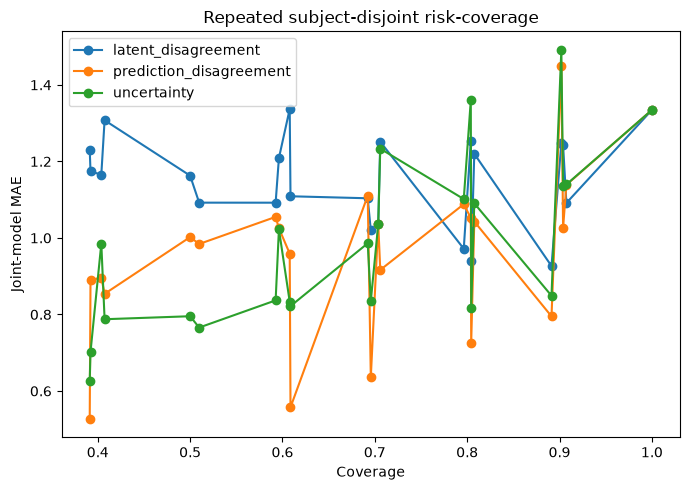

In [30]:
# ============================================================
# 21. RISK-COVERAGE SUMMARY
# ============================================================

risk_summary=(risk_coverage_repeated.groupby(["signal","coverage"]).agg(
    N_repeats=("repeat","count"), MAE_mean=("MAE","mean"), MAE_sd=("MAE","std"), MAE_median=("MAE","median"),
).reset_index())

display(risk_summary)

plt.figure(figsize=(7,5))
for signal,g in risk_summary.groupby("signal"):
    plt.plot(g.coverage,g.MAE_median,marker="o",label=signal)
plt.xlabel("Coverage")
plt.ylabel("Joint-model MAE")
plt.title("Repeated subject-disjoint risk-coverage")
plt.legend(); plt.tight_layout(); plt.show()


## 22. FreeSurfer versus learned raw-T1 representation

In [31]:
# ============================================================
# 22. FREE SURFER REPRESENTATION BENCHMARK
# ============================================================

class ViewModel(nn.Module):
    def __init__(self, input_dim, hidden=32):
        super().__init__(); self.enc=TemporalEncoderPaper(input_dim,hidden); self.head=nn.Linear(hidden,1)
    def forward(self,x,t,m):
        z=self.enc(x,t,m); return self.head(z).squeeze(-1),z

@torch.inference_mode()
def predict_view(model, frame, prep, view):
    vals=[]; zs=[]
    for batch_cpu in loader(frame,prep,False):
        b=move(batch_cpu)
        if view=="fs": p,z=model(b["fs"],b["fs_time"],b["fs_mask"])
        elif view=="raw": p,z=model(b["raw"],b["raw_time"],b["raw_mask"])
        else: p,z=model(b["clinical"],b["clinical_time"],b["clinical_mask"])
        vals.extend(p.cpu().numpy().tolist()); zs.extend(z.cpu().numpy())
    return np.asarray(vals), np.asarray(zs)


def fit_view(frame,prep,view,epochs,seed):
    seed_everything(seed)
    dim=(prep.fs_pca.n_components_ if view=="fs" else prep.raw_pca.n_components_ if view=="raw" else len(CLINICAL_FEATURES))
    model=ViewModel(dim,TEMPORAL_HIDDEN).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    crit=nn.SmoothL1Loss(); model.train()
    for _ in range(epochs):
        for batch_cpu in loader(frame,prep,True):
            b=move(batch_cpu); opt.zero_grad(set_to_none=True)
            if view=="fs": p,_=model(b["fs"],b["fs_time"],b["fs_mask"])
            elif view=="raw": p,_=model(b["raw"],b["raw_time"],b["raw_mask"])
            else: p,_=model(b["clinical"],b["clinical_time"],b["clinical_mask"])
            loss=crit(p,b["target"]); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
    model.eval(); return model


if RUN_FREESURFER_BENCHMARK:
    fb=[]
    fs_frame=sequence_df[sequence_df.n_fs>0].reset_index(drop=True)
    for r in range(FS_BENCHMARK_REPEATS):
        seed=SEED+70000+r
        sp=GroupShuffleSplit(n_splits=1,test_size=OUTER_TEST_SIZE,random_state=seed)
        ti,ei=next(sp.split(fs_frame,groups=fs_frame.subject_id))
        tr=fs_frame.iloc[ti].reset_index(drop=True); te=fs_frame.iloc[ei].reset_index(drop=True)
        prep=PaperPreprocessor().fit(tr)
        preds={}
        for view in ["raw","fs","clinical"]:
            model=fit_view(tr,prep,view,30,seed+100+len(preds))
            preds[view],_=predict_view(model,te,prep,view)
            del model; gc.collect()
            if DEVICE.type=="cuda": torch.cuda.empty_cache()
        raw_clin=np.abs(preds["raw"]-preds["clinical"])
        fs_clin=np.abs(preds["fs"]-preds["clinical"])
        raw_mean=(preds["raw"]+preds["clinical"])/2
        fs_mean=(preds["fs"]+preds["clinical"])/2
        y=te.future_mmse.to_numpy()
        for name,score,pred in [("Triad_rawT1",raw_clin,raw_mean),("FreeSurfer",fs_clin,fs_mean)]:
            d=pd.DataFrame({"subject_id":te.subject_id.to_numpy(),"score":score,"abs_error":np.abs(pred-y)})
            s=d.groupby("subject_id",as_index=False).mean(numeric_only=True)
            rho,p=spearmanr(s.score,s.abs_error) if len(s)>=10 and s.score.nunique()>1 and s.abs_error.nunique()>1 else (np.nan,np.nan)
            fb.append({"repeat":r,"representation":name,"test_subjects":len(s),"prediction_MAE":mean_absolute_error(y,pred),
                       "prediction_RMSE":np.sqrt(mean_squared_error(y,pred)),"prediction_R2":r2_score(y,pred),
                       "disagreement_error_rho":rho,"disagreement_error_p":p})
        del prep; gc.collect()
    fs_benchmark=pd.DataFrame(fb)
    display(fs_benchmark)
    display(fs_benchmark.groupby("representation").agg(N_repeats=("repeat","count"),rho_median=("disagreement_error_rho","median"),
                                                         MAE_mean=("prediction_MAE","mean"),R2_mean=("prediction_R2","mean")).reset_index())
else:
    fs_benchmark=pd.DataFrame()
    print("FreeSurfer benchmark skipped.")


,repeat,representation,test_subjects,prediction_MAE,prediction_RMSE,prediction_R2,disagreement_error_rho,disagreement_error_p
0,0,Triad_rawT1,43,2.697558,5.393375,0.180680,0.456660,0.002083
1,0,FreeSurfer,43,2.538253,5.024043,0.289050,0.262609,0.088885
2,1,Triad_rawT1,43,1.525010,3.038840,0.076943,0.556478,0.000107
3,1,FreeSurfer,43,1.592759,2.771331,0.232304,0.597554,0.000023
4,2,Triad_rawT1,43,1.866296,3.138416,0.220021,0.498490,0.000669
5,2,FreeSurfer,43,1.598916,2.886483,0.340219,0.078677,0.616022


,representation,N_repeats,rho_median,MAE_mean,R2_mean
0,FreeSurfer,3,0.262609,1.909976,0.287191
1,Triad_rawT1,3,0.498490,2.029621,0.159215


## 23. Interpretation and submission gate

In [32]:
# ============================================================
# 23. PAPER SUBMISSION GATE
# ============================================================

cross=association_summary[association_summary.signal=="prediction_disagreement"]
latent=association_summary[association_summary.signal=="latent_disagreement"]
err_gain=pivot_err.cross_gain.dropna() if "cross_gain" in pivot_err else pd.Series(dtype=float)
partial=partial_repeated.partial_rho.dropna()

report=pd.DataFrame([
    {"criterion":"Repeated subject-disjoint evaluation","status":"PASS","detail":f"{N_OUTER_REPEATS} outer repeats"},
    {"criterion":"OOF/test reliability protocol matched","status":"PASS","detail":"same ensemble construction"},
    {"criterion":"Cross-modal disagreement positive across repeats","status":"PASS" if len(cross) and cross.iloc[0].fraction_positive>0.5 else "CHECK",
     "detail":f"median rho={cross.iloc[0].rho_median:.3f}" if len(cross) else "NA"},
    {"criterion":"Cross-modal disagreement improves error prediction","status":"PASS" if len(err_gain) and (err_gain>0).mean()>0.5 else "CHECK",
     "detail":f"mean MAE gain={err_gain.mean():.3f}" if len(err_gain) else "NA"},
    {"criterion":"Association survives difficulty controls","status":"PASS" if len(partial) and (partial>0).mean()>0.5 else "CHECK",
     "detail":f"positive fraction={((partial>0).mean()):.2f}" if len(partial) else "NA"},
    {"criterion":"Latent disagreement shows coherent signal","status":"PASS" if len(latent) and latent.iloc[0].fraction_positive>0.5 else "CHECK",
     "detail":f"median rho={latent.iloc[0].rho_median:.3f}" if len(latent) else "NA"},
])

display(report)

print("\nInterpretation:")
print("1. Prediction accuracy is reported as a benchmark, not the paper's central claim.")
print("2. Continuous error association and repeated-split consistency are primary reliability evidence.")
print("3. Large-error AUROC is secondary and must be accompanied by positive-event counts.")
print("4. A positive partial association is important because it weakens the case-difficulty explanation.")
print("5. The FreeSurfer benchmark asks whether the reliability phenomenon is representation-specific or generic to any structural MRI representation.")
print("6. An independent cohort such as MIRIAD remains the cleanest final external validation step before claiming generalization.")


,criterion,status,detail
0,Repeated subject-disjoint evaluation,PASS,6 outer repeats
1,OOF/test reliability protocol matched,PASS,same ensemble construction
2,Cross-modal disagreement positive across repeats,PASS,median rho=0.303
3,Cross-modal disagreement improves error predic...,PASS,mean MAE gain=0.002
4,Association survives difficulty controls,PASS,positive fraction=1.00
5,Latent disagreement shows coherent signal,CHECK,median rho=0.042



Interpretation:
1. Prediction accuracy is reported as a benchmark, not the paper's central claim.
2. Continuous error association and repeated-split consistency are primary reliability evidence.
3. Large-error AUROC is secondary and must be accompanied by positive-event counts.
4. A positive partial association is important because it weakens the case-difficulty explanation.
5. The FreeSurfer benchmark asks whether the reliability phenomenon is representation-specific or generic to any structural MRI representation.
6. An independent cohort such as MIRIAD remains the cleanest final external validation step before claiming generalization.


## 24. Save reproducible outputs

In [33]:
# ============================================================
# 24. SAVE FINAL OUTPUTS
# ============================================================

save_map={
    "performance_repeated.csv":performance_repeated,
    "performance_summary.csv":performance_summary,
    "association_repeated.csv":association_repeated,
    "association_summary.csv":association_summary,
    "partial_association_repeated.csv":partial_repeated,
    "error_prediction_repeated.csv":error_prediction_repeated,
    "error_prediction_summary.csv":error_prediction_summary,
    "large_error_repeated.csv":large_error_repeated,
    "large_error_summary.csv":large_error_summary,
    "risk_coverage_repeated.csv":risk_coverage_repeated,
    "risk_coverage_summary.csv":risk_summary,
    "fs_benchmark.csv":fs_benchmark,
    "paper_submission_gate.csv":report,
}
for name,table in save_map.items():
    table.to_csv(PAPER_OUTPUT_DIR/name,index=False)

config={
    "seed":int(SEED),"n_outer_repeats":int(N_OUTER_REPEATS),"outer_test_size":float(OUTER_TEST_SIZE),
    "n_inner_folds":int(N_INNER_FOLDS),"n_oof_members":int(N_OOF_MEMBERS),"n_test_members":int(N_TEST_MEMBERS),
    "pca_dim_raw":int(PCA_DIM_RAW),"pca_dim_fs":int(PCA_DIM_FS),"temporal_hidden":int(TEMPORAL_HIDDEN),
    "max_epochs":int(MAX_EPOCHS),"patience":int(PATIENCE),"fixed_large_error_threshold":float(FIXED_LARGE_ERROR_THRESHOLD),
    "clinical_features":CLINICAL_FEATURES,"n_freesurfer_features":int(len(FS_FEATURES)),
}
with open(PAPER_OUTPUT_DIR/"analysis_config.json","w",encoding="utf-8") as f: json.dump(config,f,indent=2)
with open(PAPER_OUTPUT_DIR/"selected_freesurfer_features.txt","w",encoding="utf-8") as f: f.write("\n".join(FS_FEATURES))

print("Saved paper-ready outputs to:", PAPER_OUTPUT_DIR)
print("Per-repeat checkpoints are in:", REPEAT_DIR)


Saved paper-ready outputs to: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS
Per-repeat checkpoints are in: C:\Projects\OASIS\oasis_raw_t1_encoder\PAPER_READY_FINAL_RESULTS\outer_repeats


# 25. What makes this version paper-ready

This notebook does not treat one favorable split as decisive. The paper-level result is the stability of the effect across repeated subject-disjoint outer splits.

The most important table should contain:

- future-outcome prediction performance for MRI, clinical, gated joint, and persistence models;
- repeated-split association between each reliability signal and absolute error;
- the within-view spread controls;
- the partial association after difficulty controls;
- out-of-sample error-prediction performance with and without cross-modal disagreement;
- the FreeSurfer representation comparison.

The primary claim should remain narrow: **cross-modal disagreement is a candidate reliability signal**. External replication in MIRIAD is still the preferred final validation before claiming that the phenomenon generalizes beyond OASIS-3.